## Number of components of the vector embeddings

In [1]:
from scipy.sparse import load_npz
import numpy as np

In [3]:
embeddings = load_npz("embeddings/abstract_embeddings_tfidf.npz")
embeddings.shape

(25877, 55750)

In [6]:
scibert = np.load("embeddings/title_embeddings_scibert.npz")['arr_0']
scibert.shape

(25877, 768)

## Nodes and links of networks

In [1]:
import networkx as nx
from scipy.sparse import load_npz

In [2]:
G = nx.from_scipy_sparse_array(load_npz("tf_idf_network/results/abstract_embeddings/abstract_tfidf_adjacency_0_2.npz"))

In [4]:
print(nx.number_connected_components(G))
print(max([len(c) for c in nx.connected_components(G)]))
print(G.size())

1061
24752
384510


## Number of connected components

We sweep the threshold on similarity from 0.15 (where we have 89 connected components) to 0.5 (where we have 25001 connected components, so very few papers connected). We want to see in particular how many nodes does the biggest component contain. We use ten different values in the range.

We never have 22 components as we would hope, but it is natural since some papers have very little abstracts or are written in another language, so they are isolated and not connected to anything.

Anyway, we will use a threshold of 0.2, so that we have one main giant component, and we will try to analyze its features. We will also try to find communities inside this network, to see if they correspond to the topics of arxiv.

## Degree distribution

The distribution looks like a power-law distribution (although this should be verified). Certainly it is not a random network.

## Other measures
### Clustering coefficient

There seems to be no relation between clustering coefficient and degree, except for the fact that of course increasing the degree also decreases the clustering coefficient. However, we always need to have a comparison with other kinds of networks (E-R and B-A).

In [21]:
from scipy.sparse import load_npz
import networkx as nx
from networks.build_networks import build_adjacency_matrix

### Eigenvalue centrality

### KNN

In [29]:
G = nx.from_scipy_sparse_array(load_npz("networks/results/abstract_embeddings/abstract_tfidf_adjacency_0_2.npz"))
G.size()

384510

## Check if there exist a link between the three nodes with highest degree

In [12]:
print(G.degree[17128])
print(G.degree[10651])
print(G.degree[9132])

1480
1328
1134


In [30]:
G.has_edge(10651, 9132)

True

In [40]:
degree_list = list(G.degree)

In [45]:
[degree_list[node][0] for node in list(G.nodes) if degree_list[node][1] == 0]

[]

In [48]:
G.nodes

NodeView((1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 2

## Scale-free graph

In [10]:
from scipy.sparse import load_npz
import networkx as nx

In [11]:
G = nx.from_scipy_sparse_array(load_npz("networks/results/scale_free_network/scale_free_network.npz"))

In [12]:
G.size()

387930

## Fit powerlaw to degree distribution

In [1]:
from scipy.sparse import load_npz
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pareto, lognorm
import numpy as np

In [3]:
G = nx.from_scipy_sparse_array(load_npz("tf_idf_network/results/abstract_embeddings/abstract_tfidf_adjacency_0_2.npz"))

In [4]:
degrees = list(G.degree)
degrees = [element[1] for element in degrees if element[1] != 0]

Power law exponent (minus 1) = 0.3679623144126221


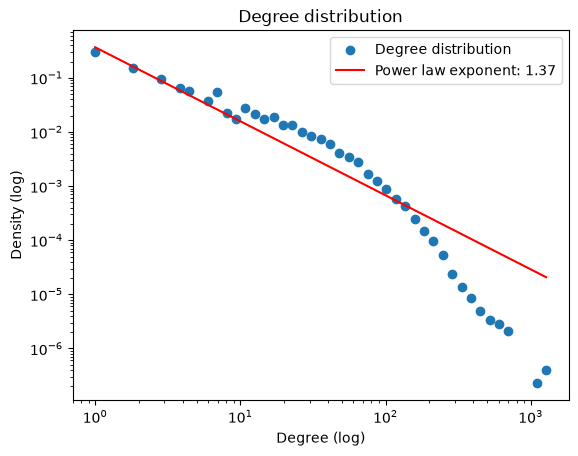

In [6]:
#fit powerlaw
plt.figure()
y, x = np.histogram(degrees, bins = np.logspace(0, np.log10(max(degrees))), density=True)
    
#the last element of y includes the last two bins of x. So x has one more element than y, which we have to cut out
plt.scatter(x[:-1], y, label = "Degree distribution")

fit_parameter, loc, scale = pareto.fit(degrees, floc = 0, fscale = 1)
#fix location and scale parameters for better fit

#define the points where the fitted function is calculated for the plot.
x_fit = np.logspace(0, np.log10(max(degrees)))
y_fit = pareto.pdf(x_fit[:-1], fit_parameter, loc = loc, scale = scale)
plt.plot(x_fit[:-1], y_fit, label = "Power law exponent: " + str(round(fit_parameter+1, 2)), color = "red")

plt.xlabel("Degree (log)")
plt.ylabel("Density (log)")
plt.title("Degree distribution")

plt.xscale("log")
plt.yscale("log")
plt.legend()
print("Power law exponent (minus 1) = " + str(fit_parameter))

It does not really look like a power law, but the exponent is a little bit higher than 3. We can anyway try to build a Barabasi-Albert graph for a comparison.

## Link shuffling

Try to see what happens if you re-shuffle links. The algorithm used does not preserve connectivity (so it can create more clusters)

In [51]:
import networkx as nx
from scipy.sparse import load_npz
from collections import Counter

In [52]:
G = nx.from_scipy_sparse_array(load_npz("networks/results/link_shuffle/link_shuffle.npz"))

In [53]:
nx.number_connected_components(G)

1014

In [54]:
Counter([len(c) for c in nx.connected_components(G)])

Counter({1: 1007, 2: 6, 24858: 1})

We continue to have one large connected component, together with other isolated nodes. However, the number of isolated nodes is lower. Thee implementation of the algorithm in Maslov and Sneppen 2002 must be investigated in order to interpret this result.

So, the degree of each node is maintained, but those links are directed to different nodes. Basically, at each iteration two random links are selected and swapped (read paper), but if those new links exist already two other links are chosen.

So the fact that one large community remains make sense, because the nodes that were isolated at the beginning remain isolated, while those that were in small isolated clusters have more probability to be connected to the giant cluster.

In [45]:
G = nx.from_scipy_sparse_array(load_npz("networks/results/abstract_embeddings/abstract_tfidf_adjacency_0_2.npz"))

In [47]:
nx.number_connected_components(G)

1061

In [50]:
Counter([len(c) for c in nx.connected_components(G)])

Counter({1: 1007, 2: 43, 3: 9, 24752: 1, 5: 1})

## Clustering using Fiedler eigenvector

In [2]:
from networks.networks_analysis import split_fiedler_eigenvector
import networkx as nx
import pickle

ModuleNotFoundError: No module named 'build_networks'

In [2]:
subgraphs_list = split_fiedler_eigenvector()

Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration
Iteration


In [3]:
[len(network) for network in subgraphs_list]

[51,
 104,
 109,
 160,
 376,
 396,
 242,
 571,
 379,
 52,
 192,
 76,
 29,
 157,
 48,
 601,
 395,
 210,
 132,
 188,
 166,
 20118]

In [ ]:
with open("networks/results/abstract_embeddings/fiedler_split", 'wb') as file:
    pickle.dump(subgraphs_list, file)

### Analysis

In [4]:
import pickle
import networkx as nx
from collections import Counter

In [ ]:
with open("tf_idf_network/results/abstract_embeddings/fiedler_split", 'rb') as file:
    subgraphs_list = pickle.load(file)

In [12]:
titles = nx.get_node_attributes(subgraphs_list[4], "Title")
topics = nx.get_node_attributes(subgraphs_list[4], "Topic")
Counter(list(topics.values()))

Counter({'Medical Physics': 278,
         'Optics': 33,
         'Computational Physics': 13,
         'Data Analysis, Statistics and Probability': 7,
         'Biological Physics': 7,
         'Applied Physics': 5,
         'Chemical Physics': 5,
         'Fluid Dynamics': 5,
         'Geophysics': 4,
         'Instrumentation and Detectors': 4,
         'Physics Education': 3,
         'Atmospheric and Oceanic Physics': 3,
         'History and Philosophy of Physics': 3,
         'Space Physics': 3,
         'Plasma Physics': 2,
         'Physics and Society': 1})

In [13]:
titles

{10250: 'A comparative study of data- and image- domain LSRTM under velocity-impedance parametrization',
 10260: 'A 240 Elements Matrix Probe with Aberration Mask for 4D Carotid Artery Computational Ultrasound Imaging',
 14370: 'Characterizing the Reliability of a Novel Upright CT for Proton Therapy',
 18466: 'A Physics-Informed Deep Learning Model for MRI Brain Motion Correction',
 14378: 'High-Resolution Magnetic Particle Imaging System Matrix Recovery Using a Vision Transformer with Residual Feature Network',
 8238: 'Supervised Diffusion-Model-Based PET Image Reconstruction',
 18498: 'Accelerating Quantitative MRI using Subspace Multiscale Energy Model (SS-MuSE)',
 12355: 'Contour-informed inter-patient deformable registration of Head-and-Neck patients',
 71: 'Incomplete Data Multi-Source Static Computed Tomography Reconstruction with Diffusion Priors and Implicit Neural Representation',
 8272: 'From Interviews to Equations: A Multi-Phase System Dynamics Model of Engineering Student

In [8]:
[len(c) for c in subgraphs_list]

[51,
 104,
 109,
 160,
 376,
 396,
 242,
 572,
 378,
 52,
 192,
 76,
 29,
 157,
 48,
 601,
 395,
 210,
 132,
 188,
 166,
 20118]

## Perturbation by node removal

Here we try to see what happens if we remove the three nodes with highest degree from the network. Do we still have one connected component, or the network breaks into many small components?

In [34]:
import networkx as nx
from scipy.sparse import load_npz
import pandas as pd

all_physics_topics = ["Accelerator Physics", "Applied Physics", "Atmospheric and Oceanic Physics", "Atomic and Molecular Clusters", 
                      "Atomic Physics", "Biological Physics", "Chemical Physics", "Classical Physics", "Computational Physics", 
                      "Data Analysis, Statistics and Probability", "Fluid Dynamics", "General Physics", "Geophysics", 
                      "History and Philosophy of Physics", "Instrumentation and Detectors", "Medical Physics", "Optics",
                        "Physics and Society", "Physics Education", "Plasma Physics", "Popular Physics", "Space Physics"]
all_papers = pd.read_csv("data/all_papers.csv")

In [29]:
G = nx.from_scipy_sparse_array(load_npz("networks/results/abstract_embeddings/abstract_tfidf_adjacency_0_2.npz"))

#create list of topics and set them as node attributes
topics_list = [all_papers['primary_cathegory'][i] if all_papers['primary_cathegory'][i] in all_physics_topics 
               else all_papers['secondary_cathegory'][i] for i in range(25877)]
topics_dictionary = dict(zip(list(range(25877)), topics_list))
nx.set_node_attributes(G, topics_dictionary, name = "Topic")

#create list of titles and set them as node attributes
titles_list = [all_papers['title'][i] for i in range(25877)]
titles_dictionary = dict(zip(list(range(25877)), titles_list))
nx.set_node_attributes(G, titles_dictionary, name = "Title")

We know that nodes 17128, 10651 and 9132 are those with degree higher than 1000

In [19]:
print(G.degree[17128])
print(G.degree[10651])
print(G.degree[9132])

1480
1328
1134


So we remove these three nodes and analyze the network again

In [31]:
G.remove_nodes_from([17128, 10651, 9132])

In [32]:
nx.number_connected_components(G)

1063

So by removing these three nodes we only have two more separated components. See how many nodes we have in each one of them.

In [33]:
[len(c) for c in nx.connected_components(G)]

[1,
 24747,
 2,
 1,
 1,
 1,
 2,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 3,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 3,
 1,
 1,
 1,


We still have one large connected component, so the graph seems to be pretty robust to the removal of the highest degree nodes. We need to see how the various centrality measures change.

### Remove more nodes

In [36]:
G = nx.from_scipy_sparse_array(load_npz("networks/results/abstract_node_removal/abstract_node_removal.npz"))

In [37]:
nx.number_connected_components(G)

1066

In [38]:
[len(c) for c in nx.connected_components(G)]

[1,
 24737,
 2,
 1,
 1,
 1,
 2,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 3,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 3,
 1,
 1,
 1,


## Find first N eigenvectors for embedding

We use N = 30 (slightly higher than the desired number of clusters)

In [23]:
from scipy.sparse import load_npz
import networkx as nx
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans
import numpy as np
from collections import Counter
import pandas as pd

all_physics_topics = ["Accelerator Physics", "Applied Physics", "Atmospheric and Oceanic Physics", "Atomic and Molecular Clusters", 
                      "Atomic Physics", "Biological Physics", "Chemical Physics", "Classical Physics", "Computational Physics", 
                      "Data Analysis, Statistics and Probability", "Fluid Dynamics", "General Physics", "Geophysics", 
                      "History and Philosophy of Physics", "Instrumentation and Detectors", "Medical Physics", "Optics",
                        "Physics and Society", "Physics Education", "Plasma Physics", "Popular Physics", "Space Physics"]
all_papers = pd.read_csv("data/all_papers.csv")

In [24]:
full_graph = nx.from_scipy_sparse_array(load_npz("networks/results/abstract_embeddings/abstract_tfidf_adjacency_0_2.npz"))

In [25]:
#create list of topics and set them as node attributes
topics_list = [all_papers['primary_cathegory'][i] if all_papers['primary_cathegory'][i] in all_physics_topics 
               else all_papers['secondary_cathegory'][i] for i in range(25877)]
topics_dictionary = dict(zip(list(range(25877)), topics_list))
nx.set_node_attributes(full_graph, topics_dictionary, name = "Topic")

#create list of titles and set them as node attributes
titles_list = [all_papers['title'][i] for i in range(25877)]
titles_dictionary = dict(zip(list(range(25877)), titles_list))
nx.set_node_attributes(full_graph, titles_dictionary, name = "Title")

In [ ]:
#keep only the largest component and remove the other nodes
largest_component = max(nx.connected_components(full_graph), key=len)
G = full_graph.subgraph(largest_component).copy()

#create laplacian matrix
laplacian_matrix = nx.laplacian_matrix(G).tocsr()

evals, evecs = eigsh(laplacian_matrix, k = 30, which ='SM', tol = 1e-6)

In [27]:
evecs

array([[ 6.35616045e-03,  9.50461385e-05, -9.62274061e-05, ...,
         1.00794178e-04,  8.02164425e-05, -1.78800757e-04],
       [ 6.35616045e-03,  9.66698322e-05, -1.02224717e-04, ...,
         7.39874713e-05,  6.55684070e-05,  7.68055715e-05],
       [ 6.35616045e-03,  9.45225756e-05, -9.14223115e-05, ...,
         8.80321239e-05,  5.96518068e-05,  6.40537666e-05],
       ...,
       [ 6.35616045e-03,  1.24243809e-04, -1.39822237e-04, ...,
         1.69000870e-04,  1.94468847e-04,  1.13792092e-04],
       [ 6.35616045e-03,  9.31146489e-05, -9.26078496e-05, ...,
         8.79135664e-05,  5.43816052e-05,  6.81928636e-05],
       [ 6.35616045e-03,  9.64533385e-05, -1.00181337e-04, ...,
         9.83263890e-05,  6.41376984e-05,  7.06466854e-05]],
      shape=(24752, 30))

Now try to use K-means clustering to create 22 clusters (equal to the number of cathegories we have) starting from the embeddings made using the eigenvectors of the Laplacian matrix

In [16]:
kmeans = KMeans(n_clusters = 22, random_state = 42)
kmeans.fit(evecs)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",22
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](22, 30)"

In [22]:
Counter(kmeans.labels_)

Counter({np.int32(0): 24683,
         np.int32(2): 6,
         np.int32(12): 5,
         np.int32(16): 5,
         np.int32(9): 4,
         np.int32(3): 4,
         np.int32(18): 4,
         np.int32(6): 3,
         np.int32(14): 3,
         np.int32(8): 3,
         np.int32(11): 3,
         np.int32(1): 3,
         np.int32(7): 3,
         np.int32(15): 3,
         np.int32(19): 3,
         np.int32(13): 3,
         np.int32(5): 3,
         np.int32(10): 3,
         np.int32(4): 2,
         np.int32(17): 2,
         np.int32(20): 2,
         np.int32(21): 2})

This method is even worse than the split based on Fiedler eigenvector: the structure of the network makes the separation based on eigenvectors difficult, and only a small number of papers is put in each cluster different from the first one.

We can try to see which papers are put in the non-main clusters.

In [34]:
clusters = dict(zip(list(G.nodes), kmeans.labels_))
nx.set_node_attributes(G, clusters, name = "Cluster")

In [49]:
#create subgraphs
subgraph = [node for node in list(G.nodes) if G.nodes[node]['Cluster'] == 6]
subgraph_network = G.subgraph(subgraph)
nx.get_node_attributes(subgraph_network, name = "Title")

{1916: 'In-Silico Investigation of 3D Quantitative Angiography for Internal Carotid Aneurysms Using Biplane Imaging and 3D Vascular Geometry Constraints',
 884: 'Self-Calibrated Epipolar Reconstruction for Assessment of Aneurysms in the Internal Carotid Artery Using In-Silico Biplane Angiograms',
 3190: 'Minimizing Human-Induced Variability in Quantitative Angiography for Robust and Explainable AI-Based Occlusion Prediction'}

In [50]:
nx.get_node_attributes(subgraph_network, name = "Topic")

{1916: 'Medical Physics', 884: 'Medical Physics', 3190: 'Medical Physics'}

The papers in the same cluster are connected as topic, but at the same time each cluster is composed only by a small number of papers, so this method is not really useful to distinguish between cathegories. At this point using the Fiedler eigenvector is better, because it can create larger clusters. This is again to the lattice-like structure of the network.

We need to try the Louvain method to see if results are better.

## Embedding using Louvain algorithm

In [1]:
import networkx as nx
from scipy.sparse import load_npz
import pandas as pd
from collections import Counter

all_physics_topics = ["Accelerator Physics", "Applied Physics", "Atmospheric and Oceanic Physics", "Atomic and Molecular Clusters", 
                      "Atomic Physics", "Biological Physics", "Chemical Physics", "Classical Physics", "Computational Physics", 
                      "Data Analysis, Statistics and Probability", "Fluid Dynamics", "General Physics", "Geophysics", 
                      "History and Philosophy of Physics", "Instrumentation and Detectors", "Medical Physics", "Optics",
                        "Physics and Society", "Physics Education", "Plasma Physics", "Popular Physics", "Space Physics"]
all_papers = pd.read_csv("data/all_papers.csv")

In [3]:
full_graph = nx.from_scipy_sparse_array(load_npz("tf_idf_network/results/abstract_embeddings/abstract_tfidf_adjacency_0_2.npz"))

#create list of topics and set them as node attributes
topics_list = [all_papers['primary_cathegory'][i] if all_papers['primary_cathegory'][i] in all_physics_topics 
               else all_papers['secondary_cathegory'][i] for i in range(25877)]
topics_dictionary = dict(zip(list(range(25877)), topics_list))
nx.set_node_attributes(full_graph, topics_dictionary, name = "Topic")

#create list of titles and set them as node attributes
titles_list = [all_papers['title'][i] for i in range(25877)]
titles_dictionary = dict(zip(list(range(25877)), titles_list))
nx.set_node_attributes(full_graph, titles_dictionary, name = "Title")

In [4]:
#keep only the largest component and remove the other nodes
largest_component = max(nx.connected_components(full_graph), key=len)
G = full_graph.subgraph(largest_component).copy()

In [5]:
import pickle
with open("tf_idf_network/results/abstract_embeddings/louvain_split", "rb") as file:
    subgraphs_list = pickle.load(file)

In [6]:
lengths = []
for subgraph in subgraphs_list:
    S = G.subgraph(subgraph)
    lengths.append(len(S))

In [7]:
lengths

[1265,
 1605,
 841,
 1670,
 1182,
 591,
 243,
 1455,
 1275,
 808,
 366,
 1912,
 6,
 1825,
 3658,
 2068,
 2033,
 1562,
 387]

In [31]:
subgraph = G.subgraph(subgraphs_list[11])
Counter(list(dict(nx.get_node_attributes(subgraph, name = "Topic")).values()))

Counter({'Optics': 1234,
         'Applied Physics': 260,
         'Instrumentation and Detectors': 76,
         'Atomic Physics': 53,
         'Computational Physics': 51,
         'Chemical Physics': 45,
         'Biological Physics': 34,
         'Medical Physics': 30,
         'Fluid Dynamics': 27,
         'Plasma Physics': 20,
         'Classical Physics': 17,
         'Geophysics': 14,
         'Atmospheric and Oceanic Physics': 12,
         'Data Analysis, Statistics and Probability': 11,
         'Accelerator Physics': 11,
         'Physics and Society': 7,
         'History and Philosophy of Physics': 3,
         'Physics Education': 2,
         'Space Physics': 2,
         'Popular Physics': 1,
         'General Physics': 1,
         'Atomic and Molecular Clusters': 1})

Here we have almost always a prevalence of one topic, which is more than double the second topic in the list. MOreover, the size of the clusters is more homogeneous, although there is one small cluster of only six papers (which, however, are all about the same topic Physics and Societ)

In [33]:
subgraph = G.subgraph(subgraphs_list[11])
[title for i, title in enumerate(list(dict(nx.get_node_attributes(subgraph, name = "Title")).values())) 
 if list(dict(nx.get_node_attributes(subgraph, name = "Topic")).values())[i] == 'Physics Education']

['PULSE-A Mission Overview: Optical Communications for Undergraduate Students',
 'Notes from the Physics Teaching Lab: Diode Laser Spectroscopy at 658 nm']

## Connections intra and inter groups

We want to find a matrix where rows and columns are the cathegories of papers, and each entry tells how many connections there are between nodes of those two cathegories. So the diagonals are just the intra-community connections.

## Pendant node removal

In [1]:
import networkx as nx
from scipy.sparse import load_npz

In [2]:
G = nx.from_scipy_sparse_array(load_npz("tf_idf_network/results/abstract_embeddings/abstract_core.npz"))

In [3]:
len(G)

23565

# FInal things

Write about the limitations: you only tried two simple methods, and most important you only used physics papers of 2025, which are very likely to have a lower range of topics with respect to the whole history of physics papers.